In [1]:
from preamble import *

2025-03-19 23:53:25,351 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


  0%|          | 0/2 [00:00<?, ?it/s]

In [2]:
# https://shone.readthedocs.io/en/latest/shone/examples/transmission.html#general-transmission-spectra
def transmission_spectrum_HengKitz17(log_atm_pressure = -1,
                                     atm_temp = 600 * u.K,
                                     log_kappa_cloud = -2,  # cloud opacity [cm2 / g]
                                     mmw=2.5,
                                     R_0=3.5 * u.R_earth,
                                     plot=False):
    """
    Compute a transmission spectrum for an atmosphere
    using the isothermal/isobaric approximation
    from Heng & Kitzmann (2017).
    """

    P_0 = 10**log_atm_pressure
    temperature = jnp.array([atm_temp.value])  # [K]
    pressure = jnp.array([P_0]) # [bar]
    chem = FastchemWrapper(temperature, pressure)
    # chem = build_fastchem_interpolator(temperature, pressure)
    vmr = chem.vmr()
    weights = chem.get_weights()

    weighted_opacities = []
    for i, spec in enumerate(species):
        op = binned_opacities[i](atm_temp.value, P_0)[0]  # cm2 / g
        col_idx = chem.get_column_index(species_name=spec)[0]
        species_weight = weights[col_idx] / mmw
    
        abund_weighted_opacity = op * species_weight * vmr[:, col_idx]
        weighted_opacities.append(abund_weighted_opacity)
    
    g = ( (c.G * M_p) / (R_0)**2 ).decompose() # surface gravity
    
    # compute the planetary radius as a function of wavelength:
    Rp = heng_kitzmann_2017.transmission_radius_isothermal_isobaric(
        weighted_opacities[0] + weighted_opacities[1] + (10**log_kappa_cloud),
        R_0.cgs.value, P_0, atm_temp, mmw, g.cgs.value
    )

    # convert to transit depth:
    transit_depth_ppm = 1e6 * (Rp / Rs.cgs.value) ** 2

    if plot:
        plt.figure()
        plt.errorbar(wavelengths, transit_depth_ppm, yerr=40e-6)
        plt.ylabel('Transit Depth (ppm)')
        plt.show()
        plt.clf()
        
    return (Rp / Rs.cgs.value), transit_depth_ppm

# Example Usage:
# Rp, transit_depth_ppm = transmission_spectrum_HengKitz17()

In [3]:
def breathing_model(phase, b1, b2, b3, b4):

    breathing = 1. + (b1 * phase) + (b2 * phase**2.) + (b3 * phase**3.) + (b4 * phase**4.)
    
    return breathing

In [4]:
def ramp_model(phase, r1, r2, r3):
    
    ramp = 1. - np.exp( (-r1 * phase) + r2) + (r3 * phase)

    return ramp

# Define the log probability

In [6]:
def lnprob(parameters, plot=False, plot_label=None, **kwargs):
    """
    Log-probability function for MCMC.

    Parameters:
    - parameters: np.ndarray, current parameter values.
    - kwargs: dict, additional arguments required for model computation.

    Returns:
    - ln_like: float, log-likelihood of the current parameter set.
    """
    ln_like = 0.0

    # Map parameters to names for easier reference
    params = {name: value for name, value in zip(params_config.keys(), parameters)}

    'Check if all priors are satisfied'
    if all(bounds[0] <= params[key] <= bounds[1] for key, bounds in priors.items()):

        'Set binning preferences and download model spectra'
        kwargs = dict(
        bin_specification = 'edges',
        bins=bin_edges,
        min=bin_edges.min(),
        max=bin_edges.max(), log=False)
        Cool, Phot = [
            bin_spectrum(
                get_spectrum(T_eff=Temp, log_g=log_g, Z=0.12, cache=True), **kwargs
            )
            for Temp in [params.get('T_spot', default_params['T_spot']), params.get('T_phot', default_params['T_phot'])] ]

        'Update Planet Parameters'
        planet_parameters['a'] = params.get('a_rstar', default_params['a_rstar'])
        planet_parameters['ecc'] = params.get('ecc', default_params['ecc'])
        planet_parameters['inclination'] = np.radians(params.get('planet_i', default_params['planet_i']))
        planet_parameters['u1'] = params.get('u1', default_params['u1'])
        planet_parameters['u2'] = params.get('u2', default_params['u2'])
        planet_parameters['rp'] = ((params.get('R_0', default_params['R_0']) * u.R_earth) / Rs).decompose()

        if visit == 'F21':
            planet_parameters['t0'] = 0
            lc_index=1
        if visit == 'S22':
            planet_parameters['t0'] = params.get('T_0', default_params['T_0'])
            lc_index=0
        
        # Update stellar parameters
        active_star.T_eff = Phot.meta['PHXTEFF']
        active_star.phot = Phot.flux.value
        active_star.wavelength = Phot.wavelength.to_value(u.m)
        active_star.temperature = jnp.array([Cool.meta['PHXTEFF']] * n_spots)
        active_star.spectrum = jnp.array([Cool.flux.value] * n_spots)
        active_star.lon = jnp.array([params.get(f"spot{i}_lon", default_params[f"spot{i}_lon"]) for i in range(1, n_spots + 1)])
        active_star.lat = jnp.array([params.get(f"spot{i}_lat", default_params[f"spot{i}_lat"]) for i in range(1, n_spots + 1)])
        active_star.rad = jnp.array([params.get(f"spot{i}_rad", default_params[f"spot{i}_rad"]) for i in range(1, n_spots + 1)])
        
        if plot:
            'Plot the stellar surface'
            active_star.plot_star(
                t0=0,
                rp=(params.get('R_0', default_params['R_0']) * u.R_earth / Rs).decompose(),  # Exoplanet radius in units of stellar radii
                a=params.get('a_rstar', default_params['a_rstar']),  # Planetary semi-major axis in units of stellar radii
                inclination=np.radians(params.get('planet_i', default_params['planet_i'])),  # Planetary orbital inclination [radians]
                ecc=params.get('ecc', default_params['ecc'])  # Planetary eccentricity
            )
            plt.title(f'Stellar Background at T0')
            plt.savefig(f'../figs/{visit}_{n_spots}spots_{nsteps}steps_whitelight_starmap.png', dpi=300)
            plt.show()
            plt.clf()
        
            'Set up the data + model plots'
            fig, axes = plt.subplots(4, 1, figsize=(6, 10))
            axes[0].set_title(f"{visit}")
            axes[0].set_xlabel("Time from midtransit")
            axes[0].set_ylabel("Relative Flux")
            axes[1].set_title("Systematic-corrected")
            axes[1].set_xlabel("Time from midtransit")
            axes[2].set_title("Residuals")
            axes[2].set_xlabel("Time from midtransit")
            axes[2].set_ylabel(r"$\sigma$")
            axes[3].set_title("Residuals")
            axes[3].set_xlabel("HST Phase")
            axes[3].set_ylabel(r"$\sigma$")
            
            total_chisq = 0
            for data_flux, relative_err, img_date, time_from_T0, direction, ramp_phase in zip(data_fluxes, relative_errs, img_dates, times_from_T0, ['Forward', 'Backward'], ramp_phases):
                
                active_star.times = time_from_T0
                lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)
            
                ramp = ramp_model(phase = ramp_phase,
                                  r1=params.get('r1', default_params['r1']),
                                  r2=params.get('r2', default_params['r2']),
                                  r3=params.get('r3', default_params['r3']),
                                  )
                bphase = (img_date-ref_time[0]+0.02) % hst_per_in_days
                # breathing = breathing_model(phase = bphase,
                #                             b1=params.get('b1', default_params['b1']),
                #                             b2=params.get('b2', default_params['b2']),
                #                             b3=params.get('b3', default_params['b3']),
                #                             b4=params.get('b4', default_params['b4']),
                #                            )
                # systematics = ramp*breathing
                systematics = ramp

                fleck_lc = lc.T[lc_index]
                fleck_lc /= np.nanmean(fleck_lc)
                model = systematics * fleck_lc
                
                normalized_model = model / np.nanmean(model)
                normalized_flux = data_flux / np.nanmean(data_flux)
                chisq = np.nansum(((normalized_flux - normalized_model) ** 2) / (relative_err ** 2))
                total_chisq+=chisq
                
                # First plot (data + model)
                axes[0].errorbar(
                    time_from_T0,
                    normalized_flux,
                    yerr=relative_err,fmt='o',ms=1,alpha=0.75)
                # Second plot (data & model)/systematics
                axes[1].errorbar(
                    time_from_T0,
                    (normalized_flux/systematics)/np.nanmean(normalized_flux/systematics),
                    yerr=relative_err,fmt='o',ms=1,alpha=0.75)
                # third plot residuals
                axes[2].scatter(
                    time_from_T0,
                    (normalized_flux-normalized_model)/relative_err,s=2,alpha=0.75)
                # fourth plot residuals in HST phase
                axes[3].scatter(
                    bphase,
                    (normalized_flux-normalized_model)/relative_err,s=2,alpha=0.75)

                # Plot the models
                axes[0].plot(
                    time_from_T0,
                    normalized_model,
                    color='k',zorder=100)
                axes[1].plot(
                    time_from_T0,
                    fleck_lc,
                    color='k',zorder=100)
                    
            plt.savefig(f'../figs/{visit}_{n_spots}spots_{nsteps}steps_whitelightcurvemodels.png',dpi=300)
            plt.show()

            dof = 2*np.sum(~np.isnan(time_from_T0)) - ndim
            reduced_chisq = total_chisq/dof
            print(f'This Models Reduced Chisq = {reduced_chisq} for {ndim} parameters and {2*np.sum(~np.isnan(time_from_T0))} data points')

            'Set up the data + model plots'
            fig, axes = plt.subplots(4, 1, figsize=(6, 10))
            axes[0].set_title(f"{visit}")
            axes[0].set_xlabel("Time from midtransit")
            axes[0].set_ylabel("Relative Flux")
            axes[0].set_xlim(-0.1,0.1)
            axes[1].set_title("Systematic-corrected")
            axes[1].set_xlabel("Time from midtransit")
            axes[1].set_xlim(-0.1,0.1)
            axes[2].set_title("Residuals")
            axes[2].set_xlabel("Time from midtransit")
            axes[2].set_ylabel(r"$\sigma$")
            axes[2].set_xlim(-0.1,0.1)
            axes[3].set_title("Residuals")
            axes[3].set_xlabel("HST Phase")
            axes[3].set_ylabel(r"$\sigma$")
                
            for data_flux, relative_err, img_date, time_from_T0, direction, ramp_phase in zip(data_fluxes, relative_errs, img_dates, times_from_T0, ['Forward', 'Backward'], ramp_phases):
                
                active_star.times = time_from_T0
                
                lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)

                ramp = ramp_model(phase = ramp_phase,
                                  r1=params.get('r1', default_params['r1']),
                                  r2=params.get('r2', default_params['r2']),
                                  r3=params.get('r3', default_params['r3']) )
                bphase = (img_date-ref_time[0]+0.02) % hst_per_in_days
                # breathing = breathing_model(phase = bphase,
                #                             b1=params.get('b1', default_params['b1']),
                #                             b2=params.get('b2', default_params['b2']),
                #                             b3=params.get('b3', default_params['b3']),
                #                             b4=params.get('b4', default_params['b4']),
                #                            )
                # systematics = ramp*breathing
                systematics = ramp
            
                fleck_lc = lc.T[lc_index]
                fleck_lc /= np.nanmean(fleck_lc)
                model = systematics * fleck_lc
                
                normalized_model = model / np.nanmean(model)
                normalized_flux = data_flux / np.nanmean(data_flux)
                chisq = np.nansum(((normalized_flux - normalized_model) ** 2) / (relative_err ** 2))
                total_chisq+=chisq
                
                # First plot (data + model)
                axes[0].errorbar(
                    time_from_T0,
                    normalized_flux,
                    yerr=relative_err,fmt='o',ms=1,alpha=0.75)
                # Second plot (data & model)/systematics
                axes[1].errorbar(
                    time_from_T0,
                    (normalized_flux/systematics)/np.nanmean(normalized_flux/systematics),
                    yerr=relative_err,fmt='o',ms=1,alpha=0.75)
                # third plot residuals
                axes[2].scatter(
                    time_from_T0,
                    (normalized_flux-normalized_model)/relative_err,s=2,alpha=0.75)
                # fourth plot residuals in HST phase
                axes[3].scatter(
                    bphase,
                    (normalized_flux-normalized_model)/relative_err,s=2,alpha=0.75)

                # Plot the models
                axes[0].plot(
                    time_from_T0,
                    normalized_model,
                    color='k',zorder=100)
                axes[1].plot(
                    time_from_T0,
                    fleck_lc,
                    color='k',zorder=100)

            axes[3].set_xlim(np.nanmin(bphase),np.nanmax(bphase))
            plt.savefig(f'../figs/{visit}_{n_spots}spots_{nsteps}steps_whitelightcurvemodels_zoomedin.png',dpi=300)
            plt.show()
            
        for data_flux, relative_err, img_date, time_from_T0, direction, ramp_phase in zip(data_fluxes, relative_errs, img_dates, times_from_T0, ['Forward', 'Backward'], ramp_phases):
            
            active_star.times = time_from_T0
            
            lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)
            
            ramp = ramp_model(phase = ramp_phase,
                              r1=params.get('r1', default_params['r1']),
                              r2=params.get('r2', default_params['r2']),
                              r3=params.get('r3', default_params['r3']),
                              )
            bphase = (img_date-ref_time[0]+0.02) % hst_per_in_days
            # breathing = breathing_model(phase = bphase,
            #                             b1=params.get('b1', default_params['b1']),
            #                             b2=params.get('b2', default_params['b2']),
            #                             b3=params.get('b3', default_params['b3']),
            #                             b4=params.get('b4', default_params['b4']),
            #                            )
            # systematics = ramp*breathing
            systematics = ramp
            
            fleck_lc = lc.T[lc_index]
        
            fleck_lc /= np.nanmean(fleck_lc)
            model = systematics * fleck_lc
            normalized_model = model / np.nanmean(model)
            normalized_flux = data_flux / np.nanmean(data_flux)
            chisq = np.nansum(((normalized_flux - normalized_model) ** 2) / (relative_err ** 2))
            err_weight = np.nansum(1.0 / np.sqrt(2.0 * np.pi * (relative_err)))
        
            ln_like += (err_weight - 0.5 * chisq)      

        return ln_like

    else:
        return -np.inf

## Set up MCMC

In [8]:
F21_default_params={
    # Ramp Model Parameters
    "r1": 18.131,#17.83,
    "r2": -7.006,#-6.99,
    "r3": 3.76445130e-04,#0.00022,
    #Breathing params
    "b1":0,
    "b2":0,
    "b3":0,
    "b4":0,
    "phase_offset":0.02,
    # Transit Parameters
    "T_0":0.0,
    "u1": 2.24026301e-01,#0.215,
    "u2": 3.61541444e-01,#0.37,
    "R_0": 3.67754833e+00,#3.67,
    "a_rstar": 1.84869028e+01,#18.57,
    "ecc": 3.56870453e-02,#0.031,
    'planet_i': 89.5, # Range from 85 to 90 deg, or 1.47-1.57radians
    "stellar_i":85.0,
    "T_spot": 3100,
    "T_phot": 4000,
    "spot1_lon": -1.19811082e+00,#-1.195,
    "spot1_lat": 8.58609899e-01,#0.853,
    "spot1_rad": 5.04794800e-01,#0.527,
    "spot2_lon": 1.31768813e+00,#1.314,
    "spot2_lat": 2.42210447,#2.445,
    "spot2_rad": 5.43939347e-01,#0.559,
    "spot3_lon": 5.31639904e-02,#0.0665,
    "spot3_lat": 1.51120520e+00,#1.497,
    "spot3_rad": 2.96138370e-01,#0.315
}

S22_default_params={
    # Ramp Model Parameters
    "r1": 1.75472009e+01,
    "r2": -6.66782019e+00,
    "r3": 1.71988755e-05,
    #Breathing params
    "b1":0,
    "b2":0,
    "b3":0,
    "b4":0,
    "phase_offset":0.02,
    # Transit Parameters
    "T_0":0.0,
    "u1": 2.68077234e-01,
    "u2": 3.67120743e-01,
    "R_0": 3.70224111e+00,
    "a_rstar": 1.81965974e+01,
    "ecc": 5.18365421e-02,
    'planet_i': 89.5, # Range from 85 to 90 deg, or 1.47-1.57radians
    # Stellar Parameters
    "stellar_i":85.0,
    "T_spot": 3100,
    "T_phot": 4000,
    "spot1_lon": -1.22579624e+00,
    "spot1_lat": 9.38377223e-01,
    "spot1_rad": 5.52454959e-01,
    "spot2_lon": 1.26379405e+00,
    "spot2_lat": 2.43726084e+00,
    "spot2_rad": 5.73546065e-01,
    "spot3_lon": 8.15560837e-02,
    "spot3_lat": 1.47316804e+00, 
    "spot3_rad": 3.26853440e-01,}

F21_params_config={
    # Ramp Model Parameters
    "r1": (17.0,18.5),
    "r2": (-7.0,-6.5),
    "r3": (0.00001,0.0001),
    #Breathing params
    # "b1":(-0.02,0),
    # "b2":(0.7, 1.0),
    # "b3":(-20,20),
    # "b4":(10,20),
    # "phase_offset":(0,0.02),
    # Transit 
    "u1": (0.25,0.29),
    "u2": (0.36,0.395),
    "R_0": (3.55,3.75),
    "a_rstar": (18,18.5),
    "ecc": (0.03,0.07),
    # Stellar Parameters
    "T_spot": (3000,3200),
    "T_phot": (3900,4100),
    "spot1_lon": (-1.21,-1.2),
    "spot1_lat": (0.9,0.92),
    "spot1_rad": (0.55,0.57),
    "spot2_lon": (1.26,1.28),
    "spot2_lat": (2.44,2.45),
    "spot2_rad": (0.57,0.58),
    "spot3_lon": (0.85,0.9),
    "spot3_lat": (1.84,1.85),
    "spot3_rad": (0.0,0.02),
}

S22_params_config={
    # Ramp Model Parameters
    "r1": (17.1,18.3),
    "r2": (-7.5,-6.5),
    "r3": (0.0001,0.0002),
    #Breathing params
    # "b1":(-0.02,0),
    # "b2":(0.7, 1.0),
    # "b3":(-20,20),
    # "b4":(10,20),
    # "phase_offset":(0,0.02),
    # Transit Parameters
    "u1": (0.25,0.29),
    "u2": (0.36,0.395),
    "R_0": (3.55,3.75),
    "a_rstar": (18,18.5),
    "ecc": (0.03,0.07),
    # Stellar Parameters
    "T_spot": (3050,3150),
    "T_phot": (3950,4150),
    "spot1_lon": (-1.21,-1.2),
    "spot1_lat": (0.9,0.92),
    "spot1_rad": (0.55,0.57),
    "spot2_lon": (1.26,1.28),
    "spot2_lat": (2.44,2.45),
    "spot2_rad": (0.57,0.58),
    "spot3_lon": (0.85,0.9),
    "spot3_lat": (1.84,1.85),
    "spot3_rad": (0.04,0.1),
}

priors={
    # Ramp Model Parameters
    "r1": (1.0,20.0),
    "r2": (-10,-2),
    "r3": (-0.001,0.001),
    #Breathing params
    # "b1":(-1,1),
    # "b2":(-10,10),
    # "b3":(-100,100),
    # "b4":(-300,300),
    # "phase_offset":(-0.5,0.5),
    # Transit Parameters
    "u1": (0.2,0.3),
    "u2": (0.2,0.4),
    "R_0": (3.2,4.0),
    "a_rstar": (17.0,20.0),
    "ecc": (0.0,0.2),
    # Stellar Parameters
    "T_spot": (2800,3500),
    "T_phot": (3600,4300),
    "spot1_lon": (-1.5,-0.7),
    "spot1_lat": (0.5,2.0),
    "spot1_rad": (0.15,0.8),
    "spot2_lon": (0.0,2.0),
    "spot2_lat": (0.0,3.0),
    "spot2_rad": (0.1,0.8),
    "spot3_lon": (0.84,0.91),
    "spot3_lat": (1.75,1.86),
    "spot3_rad": (0.0,0.1),
}

In [9]:
default_params = S22_default_params
params_config = S22_params_config

Rs = 0.8 * u.R_sun
log_g = 4.52
T_eq = 600
M_p = 10 * u.R_earth 
orbits_to_exclude = np.array([0])
orbits_to_include = np.array([1,2,3,4,5,6,7])
bin_edges = np.array([0.8120, 1.1317, 1.6392])*u.micron

n_spots = 3
nwalkers = 200
nsteps = 1500
burnin = int(0.5*nsteps)

'Set binning preferences and download initial spectra'
kwargs = dict(
    bin_specification = 'edges',
    bins=bin_edges,
    min=bin_edges.min(),
    max=bin_edges.max(),
    log=False)
Cool, Phot = [
    bin_spectrum(
        get_spectrum(T_eff=Temp, log_g=log_g, Z=0.12, cache=True), **kwargs)
    for Temp in [default_params['T_spot'], default_params['T_phot']] ]

'Initialize planet parameters and the active_star'
planet_parameters = dict(
    inclination = np.radians(default_params['planet_i']),
    a = default_params['a_rstar'],
    rp = (default_params['R_0']*u.R_earth/Rs).decompose(),
    period = 8.463,
    t0 = default_params['T_0'],
    ecc = default_params['ecc'],
    u1 = default_params['u1'],
    u2 = default_params['u2'] )
active_star = ActiveStar(
    # times=np.linspace(-0.3,0.3,200),
    inclination=np.radians(default_params['stellar_i']),  # stellar inc [rad]
    T_eff=Phot.meta['PHXTEFF'],
    wavelength=Phot.wavelength.to_value(u.m), #use data wavelength array
    phot=Phot.flux.value, #This is the model spectrum for the photosphere temp
    P_rot=4.86 )
for i in range(1, n_spots + 1):
    # Generate random values within the parameter space for each spot
    lon = default_params[f"spot{i}_lon"]
    lat = default_params[f"spot{i}_lat"]
    rad = default_params[f"spot{i}_rad"]

    spot = dict(
        lon=lon,  # Longitude [rad]
        lat=lat,  # Latitude [rad]
        rad=rad,  # Radius [R_star]
        spectrum=Cool.flux.value,  # Use provided spectrum
        temperature=Cool.meta['PHXTEFF'],  # Use provided temperature
    )
    # Add the spot to the active star
    active_star.add_spot(**spot)

# Run the MCMC

Running  S22



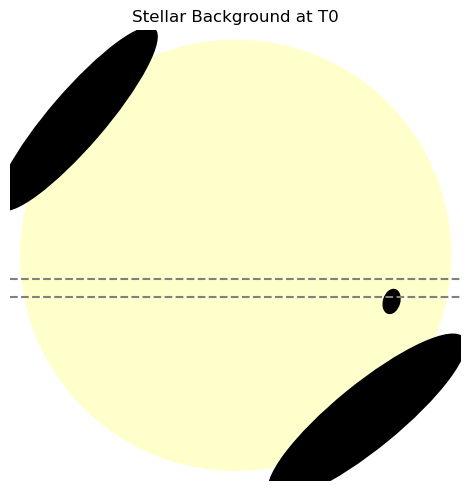

<Figure size 640x480 with 0 Axes>

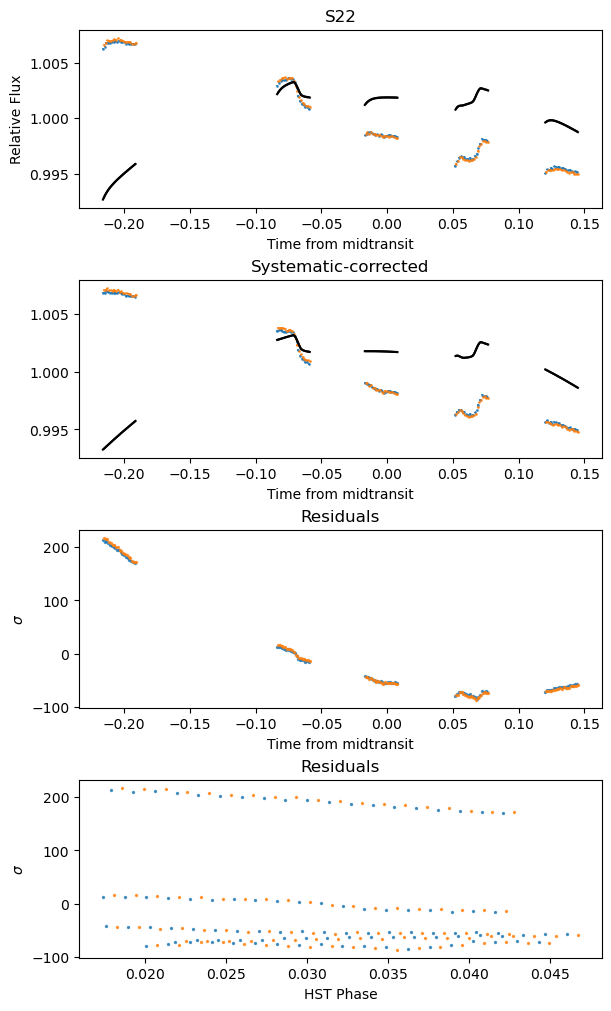

This Models Reduced Chisq = 11244.69956140351 for 19 parameters and 190 data points


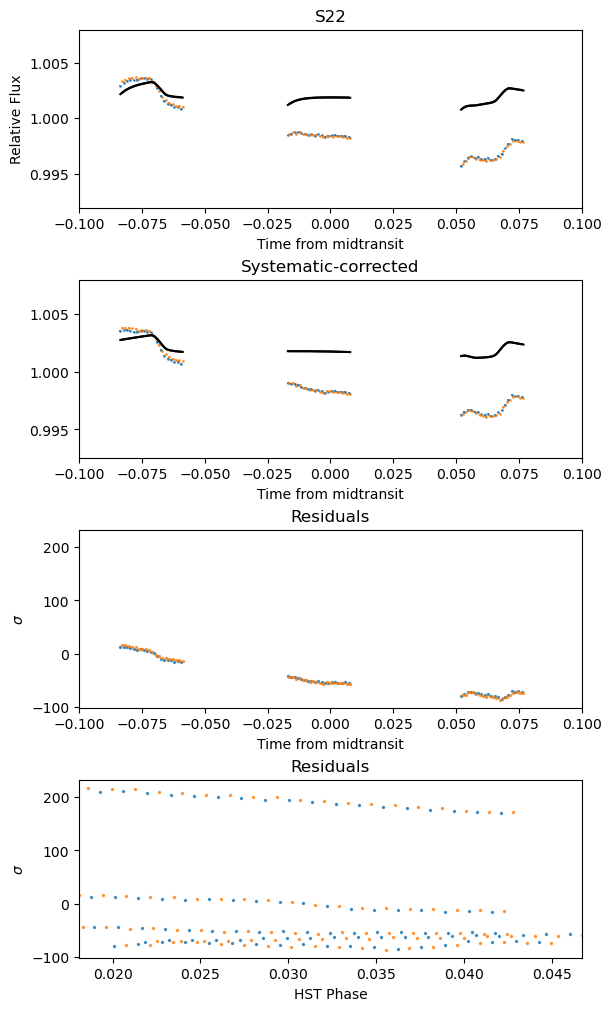

Running MCMC sampler...


100%|██████████| 1500/1500 [18:15:08<00:00, 43.81s/it]  


(Nsteps-burnin)*nwalkers/tau= 282
(Nsteps-burnin)*nwalkers/tau= 220
(Nsteps-burnin)*nwalkers/tau= 249
(Nsteps-burnin)*nwalkers/tau= 304
(Nsteps-burnin)*nwalkers/tau= 296
(Nsteps-burnin)*nwalkers/tau= 332
(Nsteps-burnin)*nwalkers/tau= 409
(Nsteps-burnin)*nwalkers/tau= 405
(Nsteps-burnin)*nwalkers/tau= 226
(Nsteps-burnin)*nwalkers/tau= 301
(Nsteps-burnin)*nwalkers/tau= 281
(Nsteps-burnin)*nwalkers/tau= 653
(Nsteps-burnin)*nwalkers/tau= 411
(Nsteps-burnin)*nwalkers/tau= 220
(Nsteps-burnin)*nwalkers/tau= 626
(Nsteps-burnin)*nwalkers/tau= 324
(Nsteps-burnin)*nwalkers/tau= 262
(Nsteps-burnin)*nwalkers/tau= 219
(Nsteps-burnin)*nwalkers/tau= 241
Highest Likelihood Parameters: [ 6.84477149e+00 -7.04104677e+00 -7.21929323e-06  2.01911468e-01
  2.18705201e-01  3.76532797e+00  1.72121051e+01  1.14829291e-01
  2.85269838e+03  3.82187693e+03 -1.21514361e+00  8.84530769e-01
  6.62681253e-01  9.27867267e-01  2.30231020e+00  5.92336081e-01
  8.84489092e-01  1.85506662e+00  9.41024281e-02]


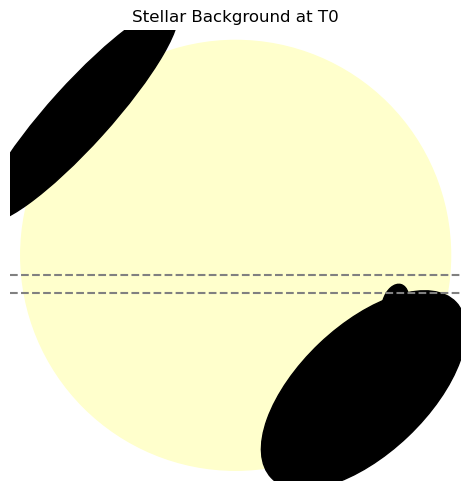

<Figure size 640x480 with 0 Axes>

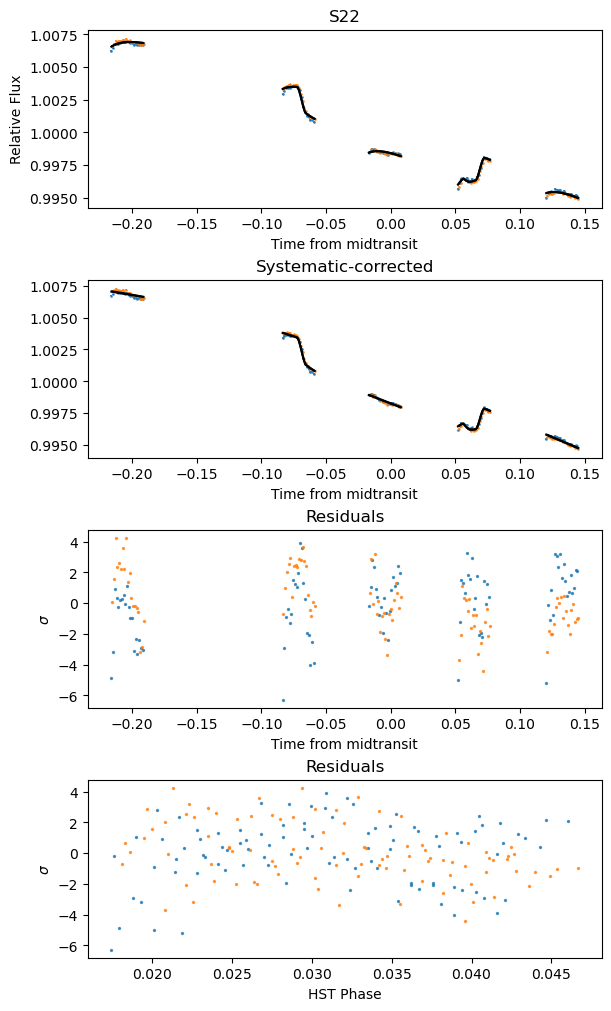

This Models Reduced Chisq = 4.4970237330386515 for 19 parameters and 190 data points


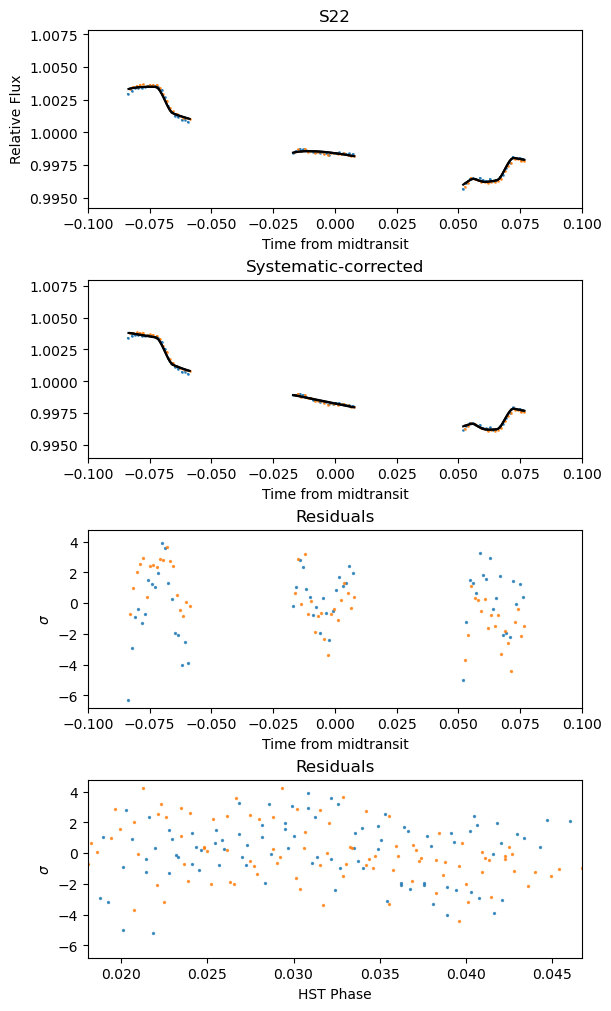

r1: 11.186636 +2.789856 -3.250366
--------------
r2: -6.859533 +0.083621 -0.181341
--------------
r3: -0.000097 +0.000186 -0.000168
--------------
u1: 0.207207 +0.007977 -0.004134
--------------
u2: 0.227924 +0.017005 -0.013308
--------------
R_0: 3.778482 +0.044268 -0.036824
--------------
a_rstar: 17.420028 +0.490984 -0.277975
--------------
ecc: 0.102607 +0.017265 -0.029280
--------------
T_spot: 2885.495105 +40.456860 -24.303790
--------------
T_phot: 3792.014202 +44.603785 -26.690032
--------------
spot1_lon: -1.224162 +0.008999 -0.005641
--------------
spot1_lat: 0.925471 +0.031303 -0.043896
--------------
spot1_rad: 0.620596 +0.034236 -0.033900
--------------
spot2_lon: 0.893779 +0.047193 -0.026719
--------------
spot2_lat: 2.390466 +0.047385 -0.066133
--------------
spot2_rad: 0.590976 +0.015360 -0.016948
--------------
spot3_lon: 0.886063 +0.010609 -0.006618
--------------
spot3_lat: 1.851661 +0.003794 -0.007119
--------------
spot3_rad: 0.086600 +0.008512 -0.009553
----------

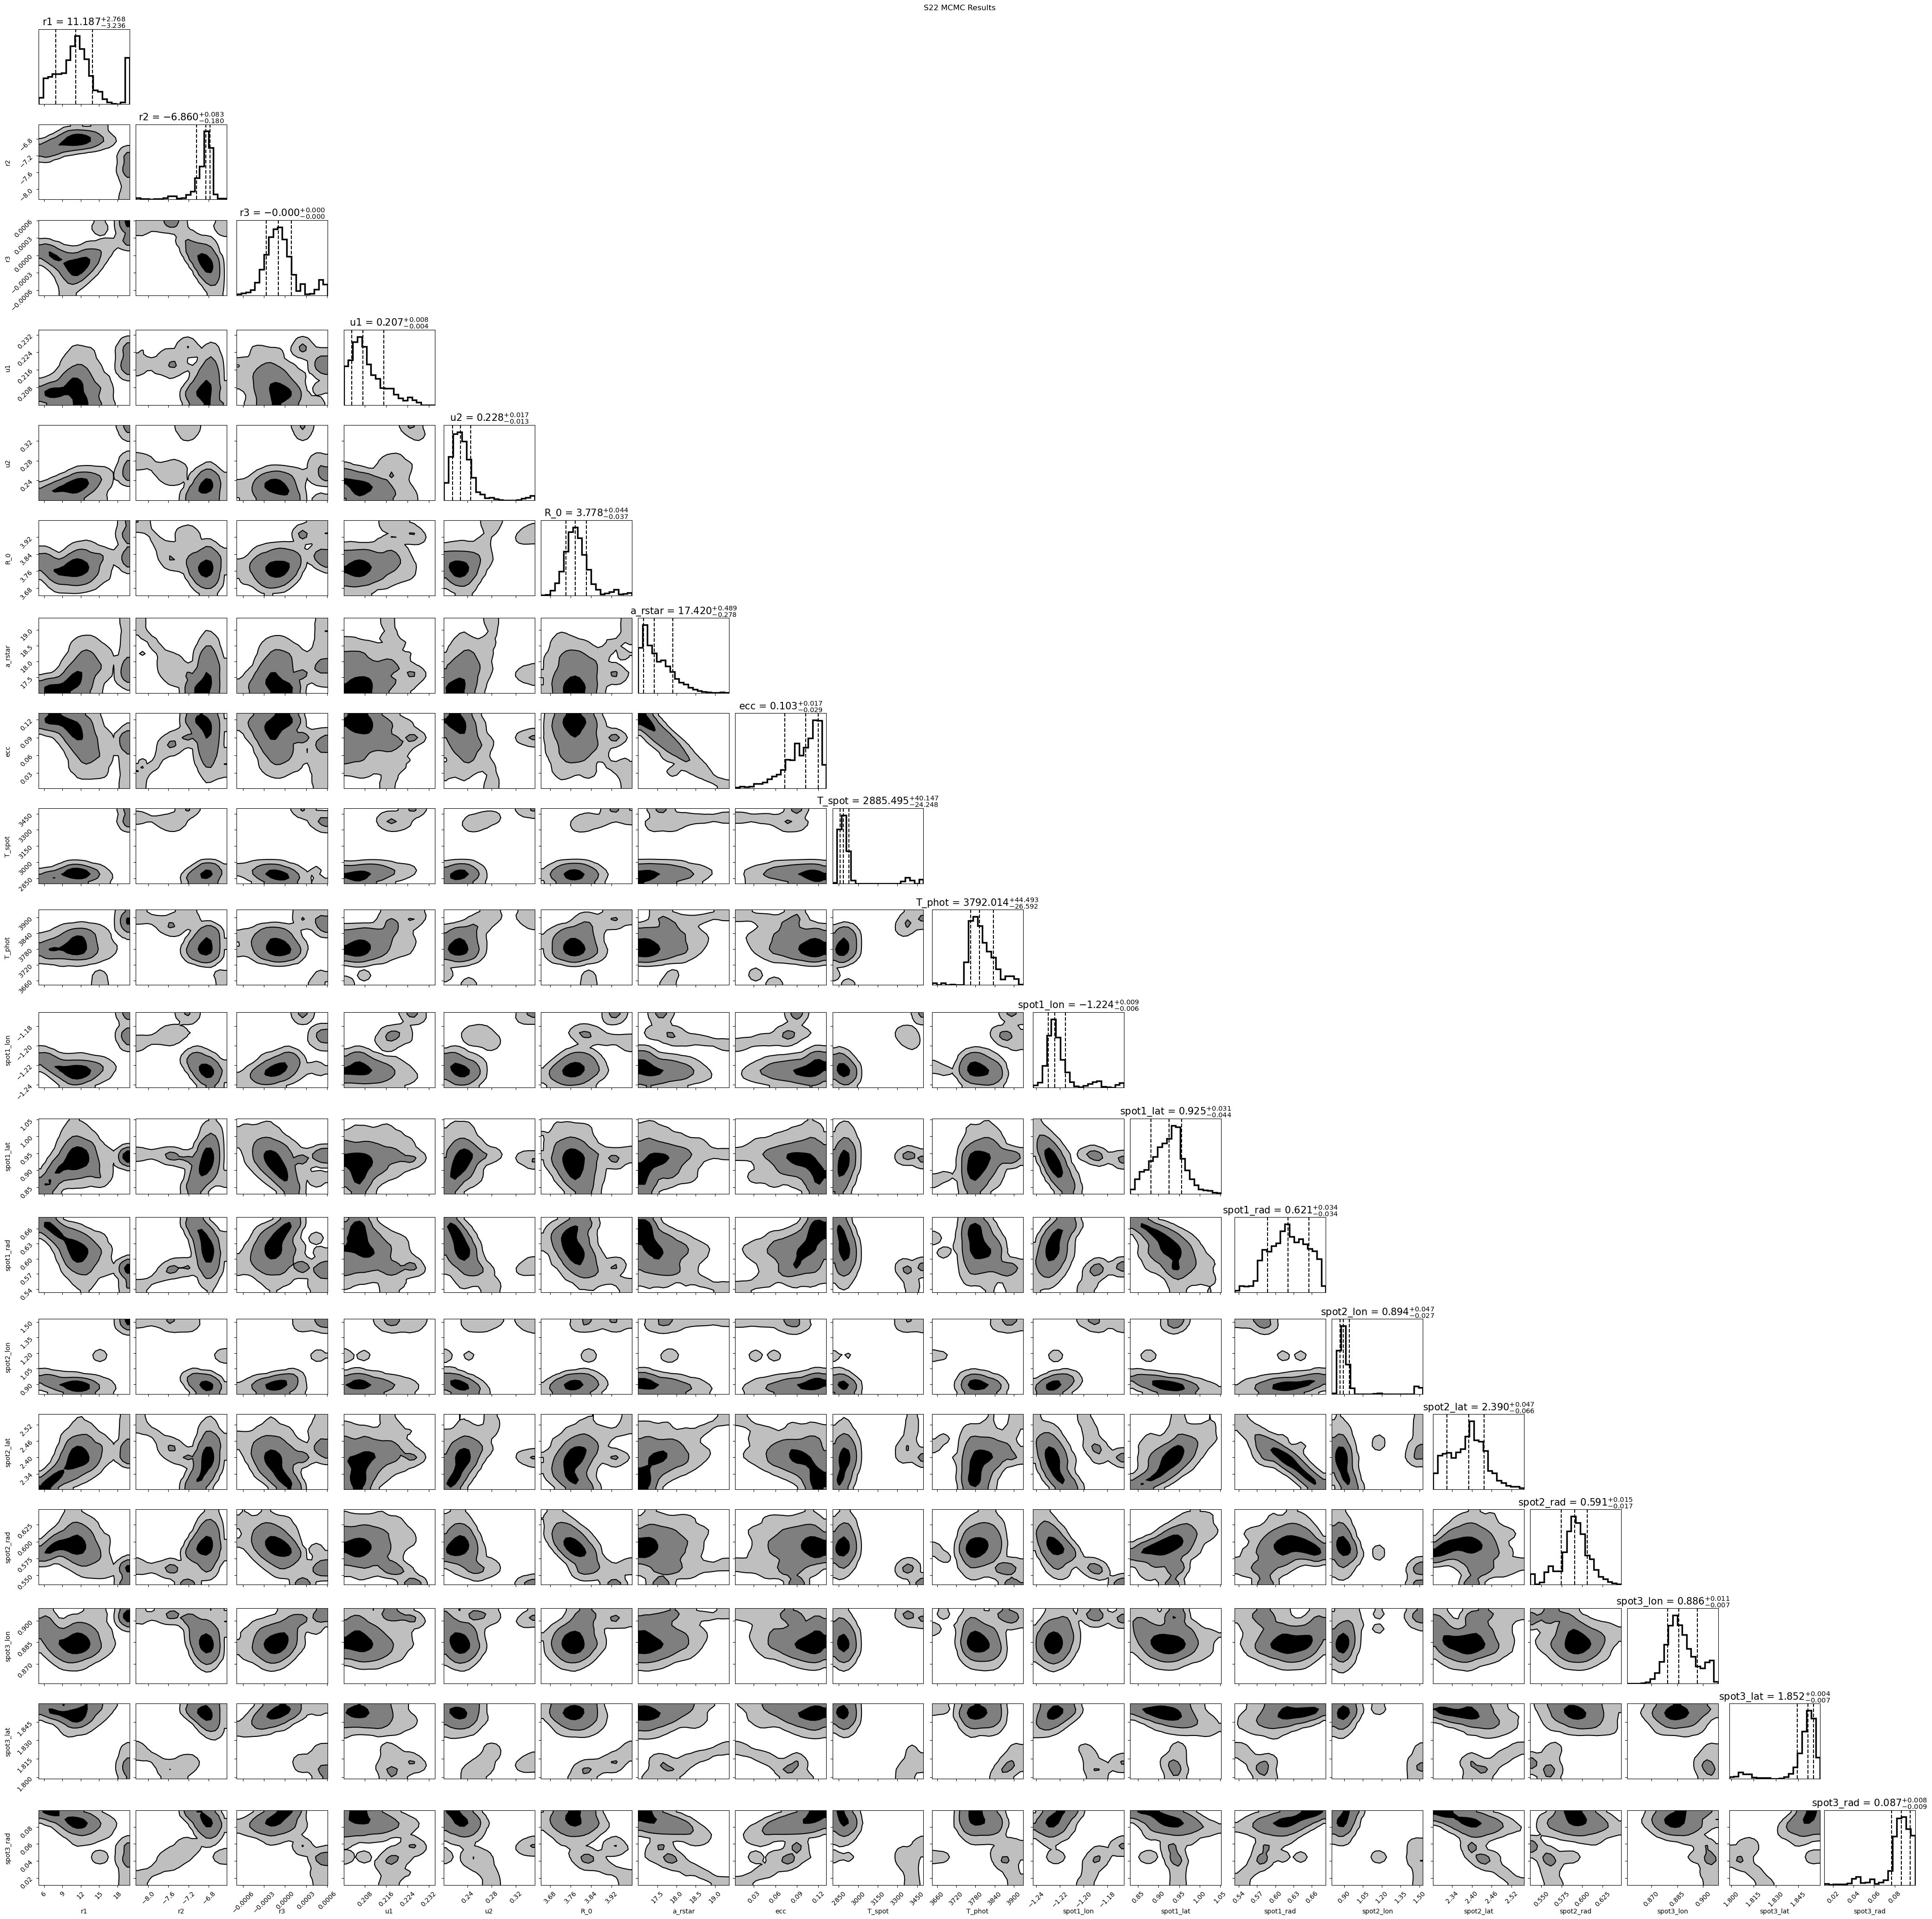

Running  F21



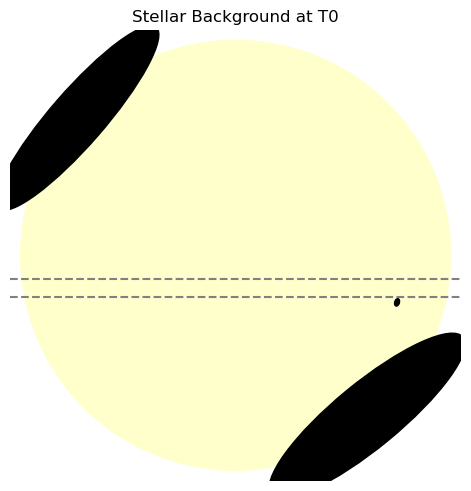

<Figure size 640x480 with 0 Axes>

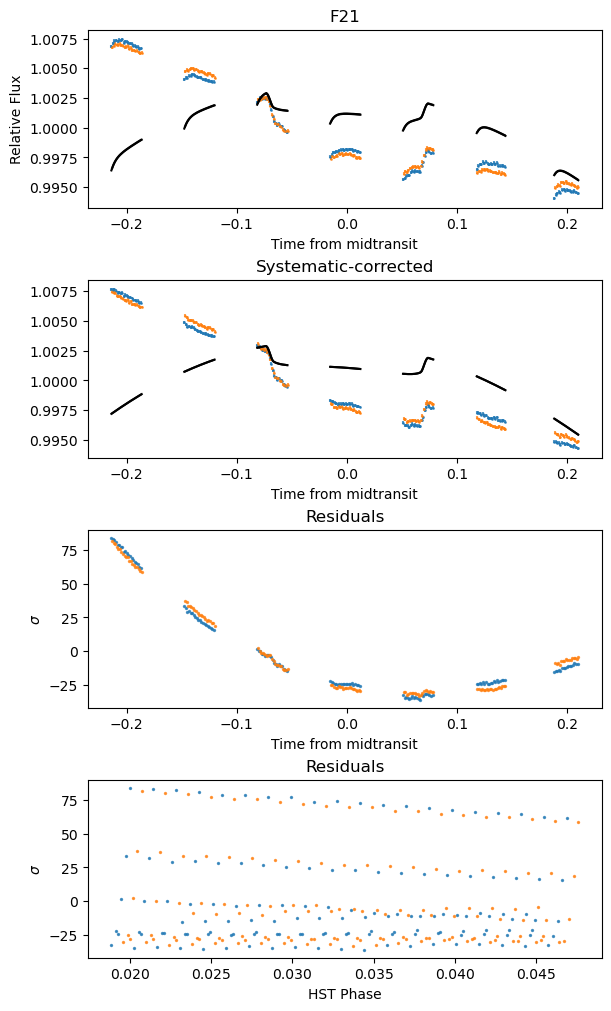

This Models Reduced Chisq = 1321.6701942231075 for 19 parameters and 270 data points


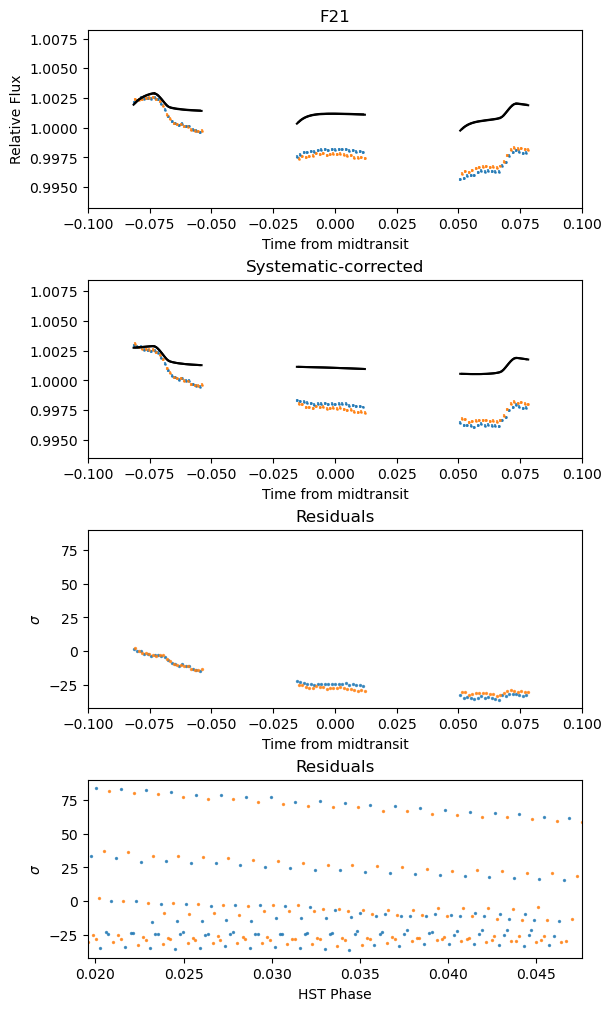

Running MCMC sampler...


100%|██████████| 1500/1500 [16:13:40<00:00, 38.95s/it]  


(Nsteps-burnin)*nwalkers/tau= 292
(Nsteps-burnin)*nwalkers/tau= 363
(Nsteps-burnin)*nwalkers/tau= 423
(Nsteps-burnin)*nwalkers/tau= 419
(Nsteps-burnin)*nwalkers/tau= 503
(Nsteps-burnin)*nwalkers/tau= 383
(Nsteps-burnin)*nwalkers/tau= 308
(Nsteps-burnin)*nwalkers/tau= 323
(Nsteps-burnin)*nwalkers/tau= 207
(Nsteps-burnin)*nwalkers/tau= 309
(Nsteps-burnin)*nwalkers/tau= 436
(Nsteps-burnin)*nwalkers/tau= 414
(Nsteps-burnin)*nwalkers/tau= 305
(Nsteps-burnin)*nwalkers/tau= 493
(Nsteps-burnin)*nwalkers/tau= 423
(Nsteps-burnin)*nwalkers/tau= 596
(Nsteps-burnin)*nwalkers/tau= 174
(Nsteps-burnin)*nwalkers/tau= 362
(Nsteps-burnin)*nwalkers/tau= 279
Highest Likelihood Parameters: [ 1.13198117e+01 -6.88049789e+00 -4.03801768e-04  2.07171681e-01
  2.22787824e-01  3.80365051e+00  1.87385199e+01  2.28459918e-02
  2.97894688e+03  4.16958790e+03 -1.11583640e+00  6.95250060e-01
  5.14764870e-01  8.54317270e-01  2.70905088e+00  5.57177670e-01
  8.96672295e-01  1.85325721e+00  4.65567232e-02]


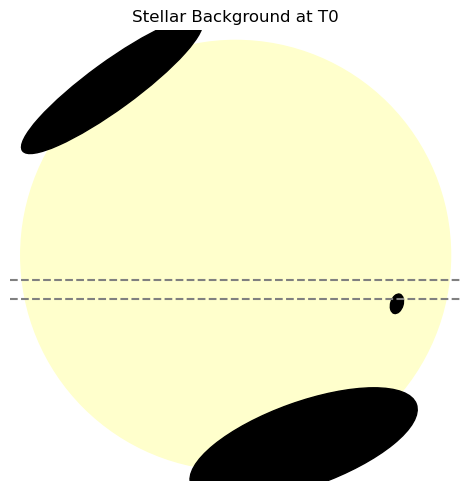

<Figure size 640x480 with 0 Axes>

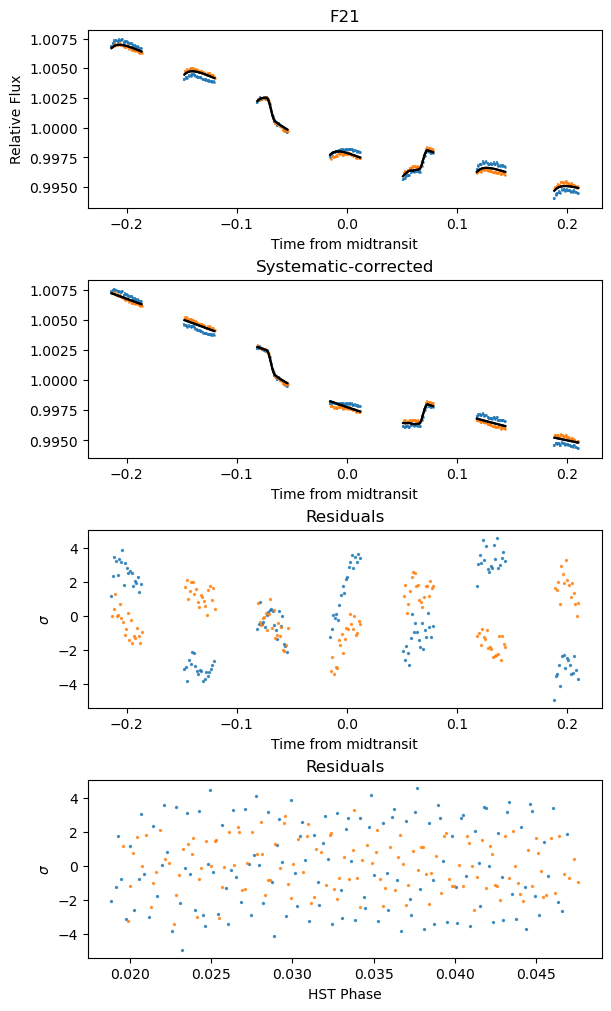

This Models Reduced Chisq = 4.697857009462151 for 19 parameters and 270 data points


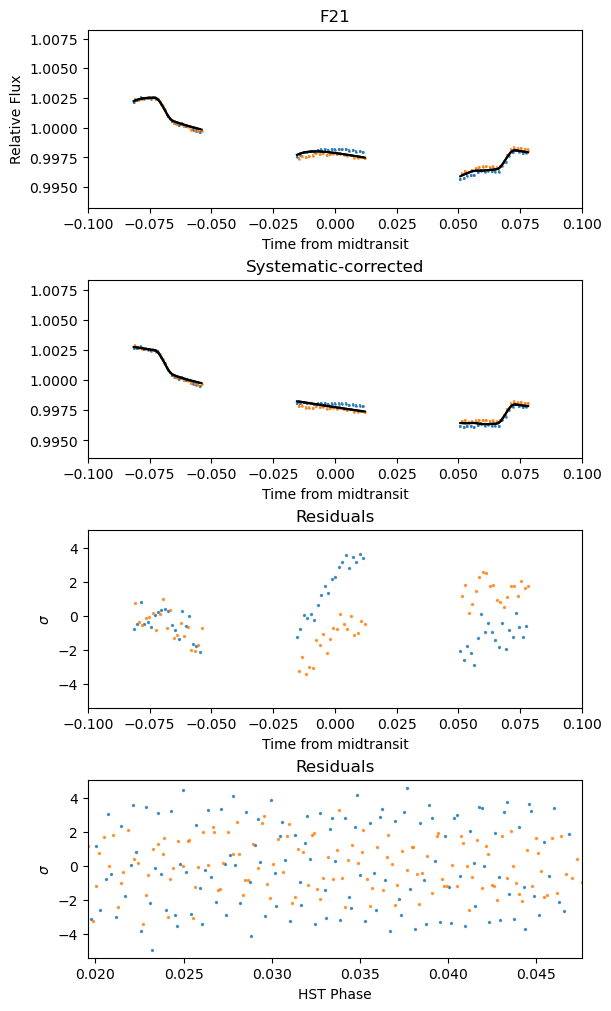

r1: 10.479004 +1.365783 -1.115946
--------------
r2: -6.910293 +0.091667 -0.091655
--------------
r3: -0.000307 +0.000179 -0.000175
--------------
u1: 0.203036 +0.002992 -0.002011
--------------
u2: 0.217365 +0.026355 -0.013343
--------------
R_0: 3.889984 +0.034243 -0.033996
--------------
a_rstar: 18.694946 +0.261427 -0.370460
--------------
ecc: 0.025178 +0.021761 -0.014855
--------------
T_spot: 3002.165414 +38.516961 -87.610707
--------------
T_phot: 4227.836614 +51.976963 -46.008555
--------------
spot1_lon: -1.134219 +0.019964 -0.013927
--------------
spot1_lat: 0.722537 +0.037777 -0.039390
--------------
spot1_rad: 0.525609 +0.023816 -0.023704
--------------
spot2_lon: 0.866766 +0.021338 -0.022769
--------------
spot2_lat: 2.669633 +0.034043 -0.033213
--------------
spot2_rad: 0.560167 +0.024038 -0.018630
--------------
spot3_lon: 0.868106 +0.018434 -0.016468
--------------
spot3_lat: 1.849817 +0.007020 -0.012710
--------------
spot3_rad: 0.032442 +0.011673 -0.011920
----------

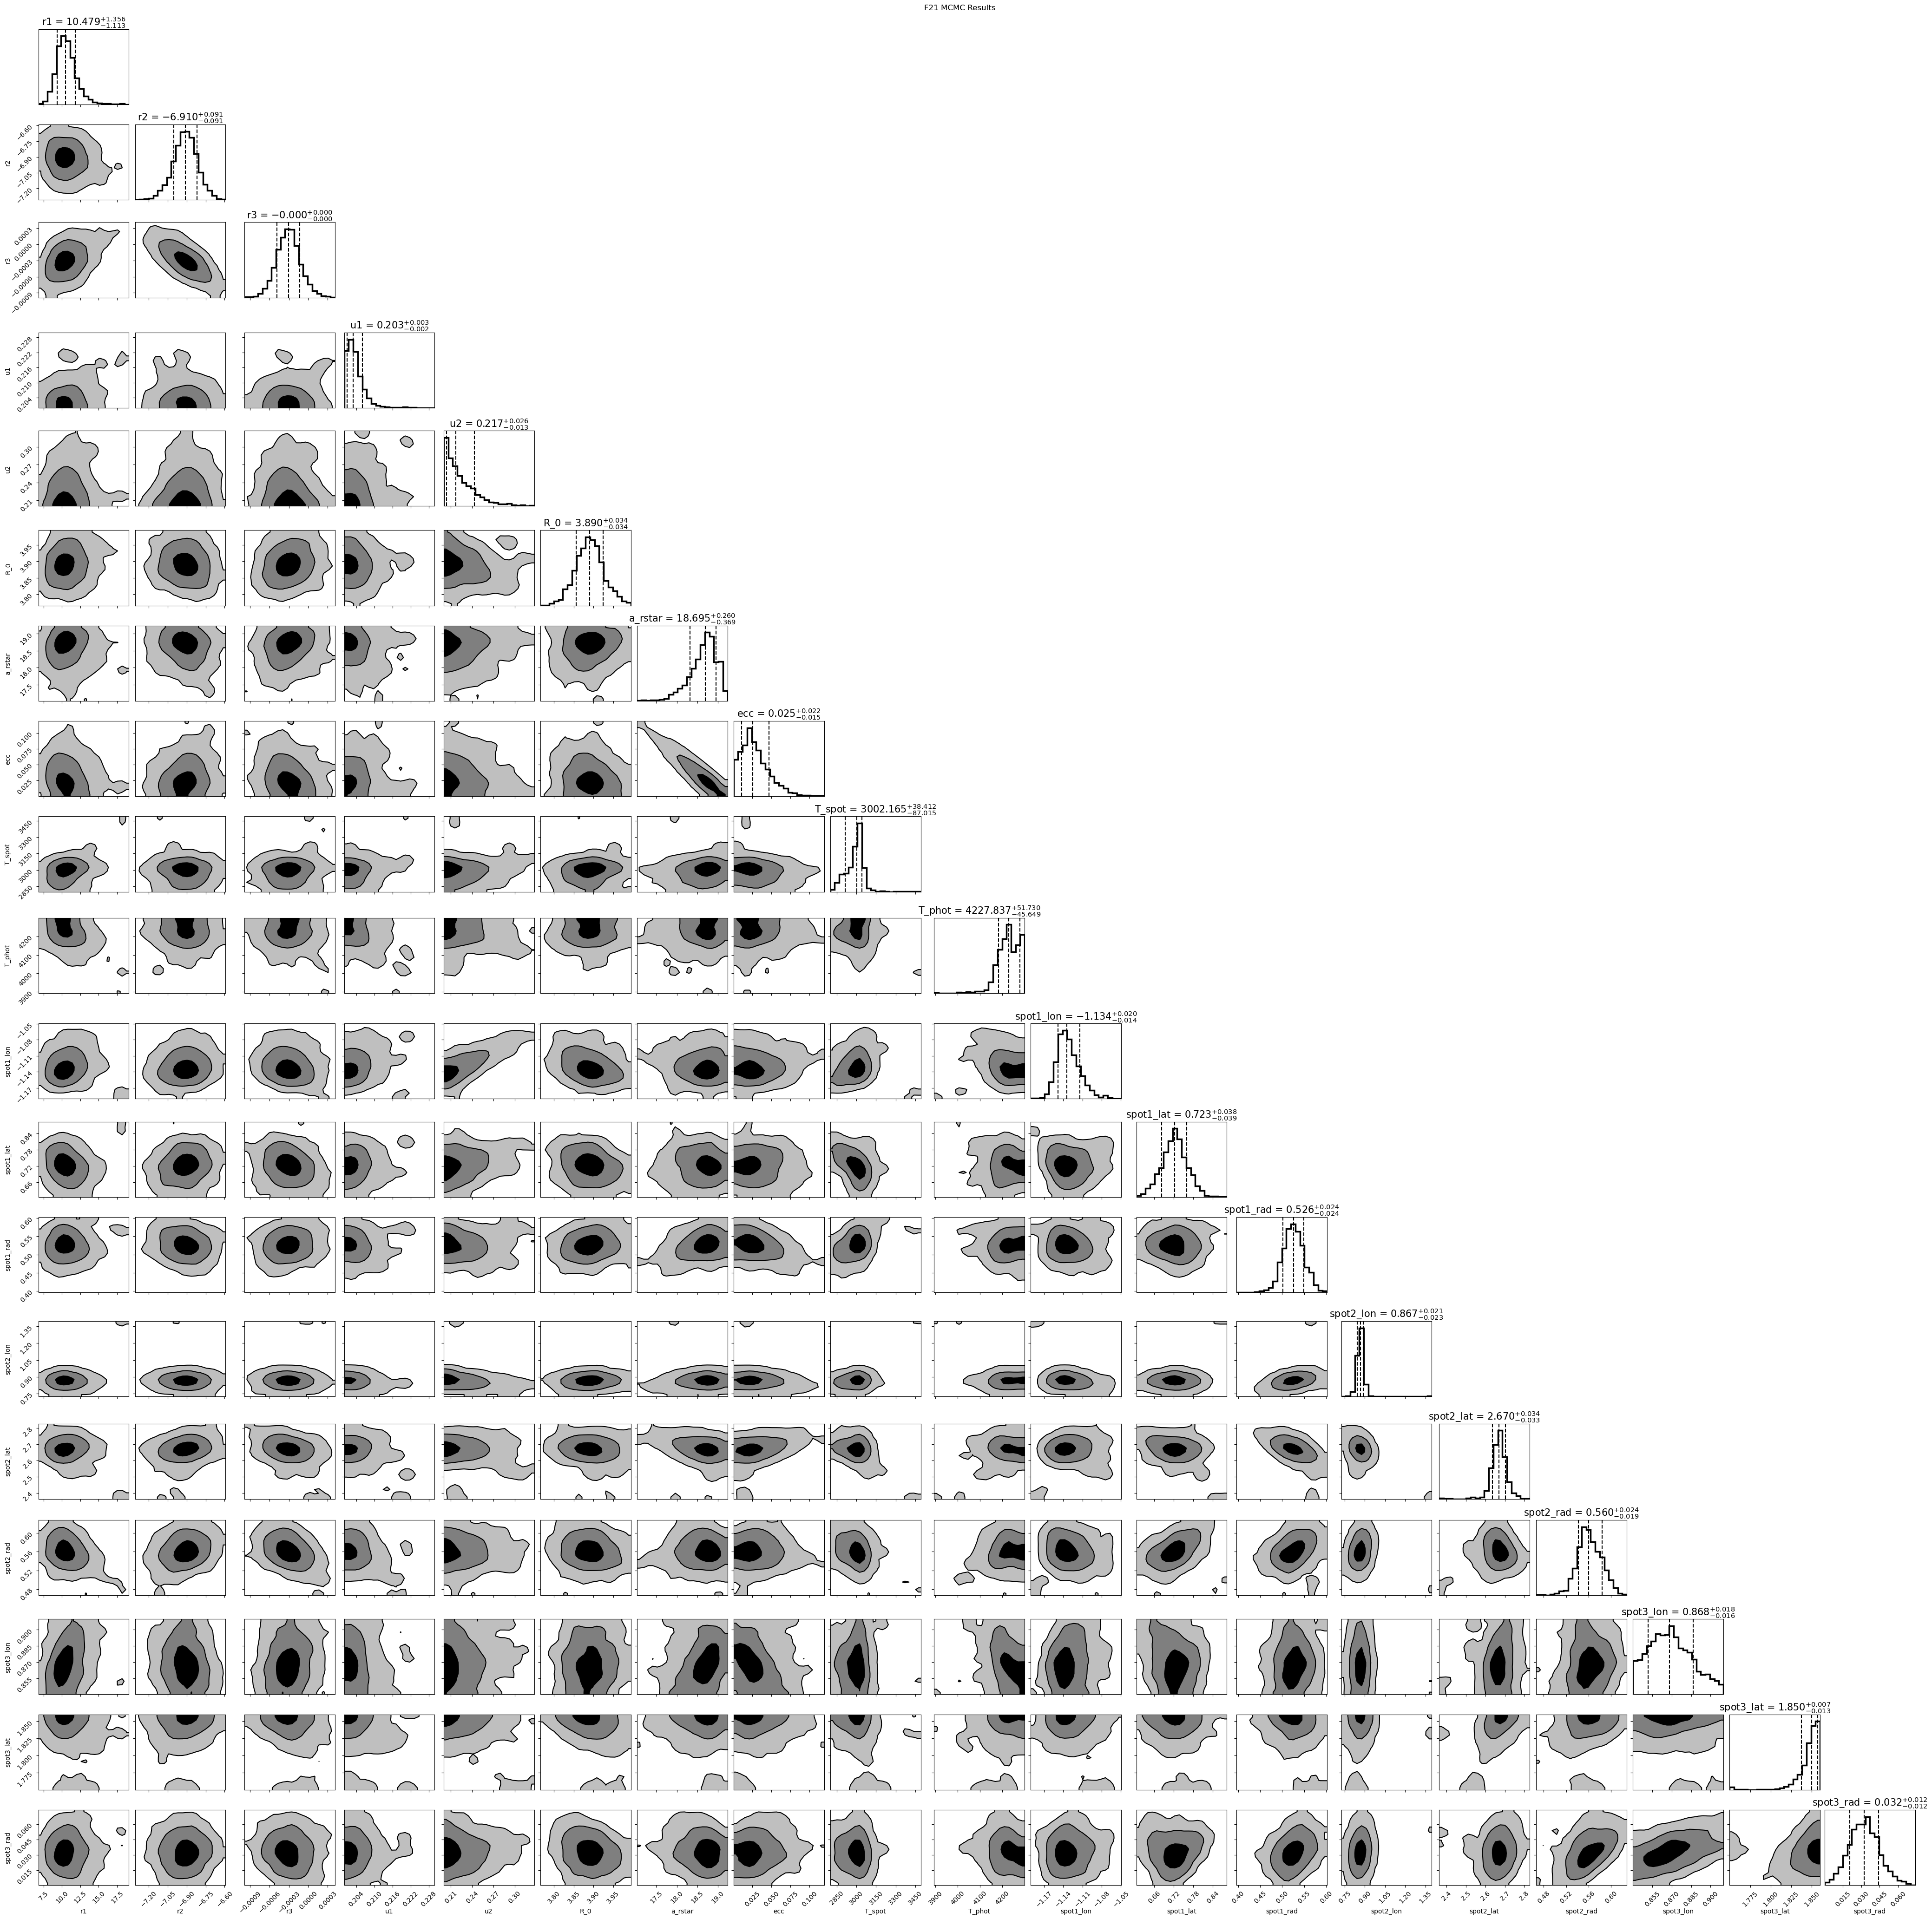

In [11]:
for visit in ['S22','F21']:

    if visit=='F21':
        default_params = F21_default_params
        params_config = F21_params_config
        orbits_to_exclude = np.array([0])
        orbits_to_include = np.array([1,2,3,4,5,6,7])
        err_inflation = 3.0

    if visit=='S22':
        default_params = S22_default_params
        params_config = S22_params_config
        orbits_to_exclude = np.array([0,2,7])
        orbits_to_include = np.array([1,3,4,5,6])
        err_inflation = 1.5
    
    print('Running ',visit)
    print('')
        
    'Extract exposure times and mid-transit times from the dictionary'
    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    exposureTime = visits[f'{visit}']['exp (s)'].value
    
    'Read in the trimmed rainbows from process_pacman_spectra.ipynb'
    data_fluxes = []
    relative_errs = []
    img_dates = []
    times_from_T0 = []
    for direction in ['Forward','Reverse']:
        rainbow = read_rainbow(f"../data/{visit}_{direction}_trimmed_pacman_spec.rainbow.npy")
        broadband_flux = np.nansum(rainbow.flux.value, axis=0)
        broadband_flux_err = np.sqrt(broadband_flux)
        relative_err = err_inflation*broadband_flux_err/broadband_flux
        # print(f'Mean Photon Error for {visit} {direction} = {np.nanmean((broadband_flux_err/broadband_flux)*1e6)}ppm')
        data_fluxes.append(broadband_flux)
        relative_errs.append(relative_err)
        img_dates.append(rainbow.time.value)
        times_from_T0.append(rainbow.time.value - predicted_T0)
    
    'Label the orbits'
    orbit = np.zeros_like(img_dates[0])
    for j in range(len(img_dates[0])):
        if j >= 1:
            if (img_dates[0][j] - img_dates[0][j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]
    
    'Trim the first point from each orbit'
    ref_time = []
    for o in np.unique(orbit):
        first_index = np.where(orbit == o)[0][0]
        ref_time.append(img_dates[0][first_index])
        for j in range(2):
            data_fluxes[j][first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
            relative_errs[j][first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
            img_dates[j][first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
            times_from_T0[j][first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan

    'Set data to nan if it was in the pre-defined list of orbits to exclude'
    for orbit_to_exclude in orbits_to_exclude:
        for j in range(2):
            data_fluxes[j][orbit == orbit_to_exclude] = np.nan
            relative_errs[j][orbit == orbit_to_exclude] = np.nan
            img_dates[j][orbit == orbit_to_exclude] = np.nan
            times_from_T0[j][orbit == orbit_to_exclude] = np.nan
        # orbit[orbit==orbit_to_exclude] = np.nan
            
    # 'Remove nan data'
    # for j in range(2):
    #     # Mask to identify non-NaN values
    #     mask = ~np.isnan(img_dates[j])
    #     # print(mask)
    #     # Redefine each array by excluding NaN values
    #     data_fluxes[j] = data_fluxes[j][:, mask]
    #     relative_errs[j] = relative_errs[j][:, mask]
    #     img_dates[j] = img_dates[j][mask]
    #     times_from_T0[j] = times_from_T0[j][mask]
    # orbits = orbit[mask]
    
    'Populate ramp_phase time arrays'
    ramp_phases=[0,0]
    for j in range(2):
        phase_list=[]
        for o in [0,1,2,3,4,5,6,7]:
            rphase = (img_dates[j][orbit==o] - ref_time[o]) / hst_per_in_days     # the data point at time "epoch" will be the zero-point; convert int phase by division through period
            phase_list.append(rphase)
        ramp_phases[j] = np.concatenate(phase_list)

    ndim = len(priors)
    variable_names = list(params_config.keys())
    p0 = initialize_walkers(nwalkers, params_config)
    
    # Select a random set of parameters
    example_params = p0[np.random.randint(0, nwalkers - 1), :]
    # print(example_params)
    # Call lnprob with the selected parameters and plot=True
    lnprob(example_params, plot=True)
    
    'Set up MCMC'
    label=f'{visit}_{nsteps}steps_whitelight_{n_spots}spots_model'
    samples_fname = f"../data/samples/{label}.h5"
    backend = emcee.backends.HDFBackend(samples_fname)
    backend.reset(nwalkers, ndim)        
    sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob,backend=backend)
    
    'Run the MCMC'
    print('Running MCMC sampler...')
    result = sampler.run_mcmc(p0, nsteps, store=True, progress=True)
    samples = sampler.chain[:, burnin:, :].reshape((-1, ndim)).T
    
    'Check for convergence (all should be > 100)'
    for i in range(len(samples)):
        tau_f = emcee.autocorr.integrated_time(samples[i])
        print('(Nsteps-burnin)*nwalkers/tau=',int((nsteps-burnin)*nwalkers/tau_f))
    
    'Return the Most likely set of parameters'
    flat_log_prob = sampler.get_log_prob(discard=burnin, flat=True)
    best_index = np.argmax(flat_log_prob)  # Index of the highest log-probability
    highest_prob_params = samples[:, best_index]
    print("Highest Likelihood Parameters:", highest_prob_params)
    lnprob(highest_prob_params, plot=True)
    
    'Extract and display best-fit parameters and uncertainties'
    median_params = []
    err_upper = []
    err_lower = []
    for i, param_samples in enumerate(samples):
        sig_1_results = np.percentile(param_samples, [15.9, 50.0, 84.1])
        median_params.append(sig_1_results[1])
        err_upper.append(sig_1_results[2] - sig_1_results[1])
        err_lower.append(sig_1_results[1] - sig_1_results[0])
    params_dict = {name: median_params[i] for i, name in enumerate(params_config.keys())}
    for i, label in enumerate(variable_names):
        print(f"{label}: {median_params[i]:.6f} +{err_upper[i]:.6f} -{err_lower[i]:.6f}")
        print("--------------")
    
    'Make corner plot'
    rng = 0.9995
    fig = corner.corner( 
        samples.T,show_titles=True, labels=variable_names,
        range=[rng]*ndim,smooth=1,quantiles=(0.16, 0.5, 0.84),
        fill_contours=True, plot_datapoints=False,title_kwargs={"fontsize": 15},title_fmt='.3f',
        hist_kwargs={"linewidth": 2.5},levels=[(1-np.exp(-0.5)),(1-np.exp(-2)),(1-np.exp(-4.5))])
    plt.suptitle(f"{visit} MCMC Results")
    plt.savefig(f'../figs/{visit}_{n_spots}spots_{nsteps}steps_whitelight_corner.png',dpi=100)
    plt.show()